# Домашняя работа №2: Бейзлайн-модели — Предсказание успеха фильма

**Курс:** Машинное обучение и нейросети  
**Студент:** Шафоростов Данила 409879  
**Задание:** Построить и оценить качество бейзлайна



---
## 1. Установка зависимостей и импорты

In [1]:
%%capture
!pip install opendatasets category_encoders -q

In [2]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import opendatasets as od

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)
from category_encoders import TargetEncoder

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 123

---
## 2. Загрузка и воспроизведение предобработки

In [3]:
print("Загрузка датасета TMDB 5000 Movie Dataset...")
od.download("https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata")

Загрузка датасета TMDB 5000 Movie Dataset...
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Mogohars
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata


100%|██████████| 8.89M/8.89M [00:01<00:00, 6.54MB/s]


In [4]:
df_raw = pd.read_csv('tmdb-movie-metadata/tmdb_5000_movies.csv')

print(f"Размер исходного датасета: {df_raw.shape[0]} строк x {df_raw.shape[1]} столбцов")

Размер исходного датасета: 4803 строк x 20 столбцов


In [5]:
def extract_first_genre(genres_str):
    """Извлекает первый жанр из JSON-поля genres."""
    try:
        genres = json.loads(genres_str.replace("'", '"'))
        return genres[0]['name'] if genres else 'Unknown'
    except Exception:
        return 'Unknown'


df = df_raw.copy()

df['genre'] = df['genres'].apply(extract_first_genre)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

df = df[(df['budget'] > 0) & (df['revenue'] > 0)].reset_index(drop=True)

df['roi'] = df['revenue'] / df['budget']
df['success'] = (df['roi'] >= 2.0).astype(int)


FEATURE_COLS = [
    'budget',
    'runtime',
    'vote_average',
    'genre',
    'original_language',
    'release_year',
    'release_month',
]
TARGET_COL = 'success'

df = df[FEATURE_COLS + [TARGET_COL]].copy()

print(f"Размер после фильтрации: {df.shape[0]} строк x {df.shape[1]} столбцов")
print(f"\nПропуски:\n{df.isna().sum()}")
df.head()

Размер после фильтрации: 3229 строк x 8 столбцов

Пропуски:
budget               0
runtime              0
vote_average         0
genre                0
original_language    0
release_year         0
release_month        0
success              0
dtype: int64


,budget,runtime,vote_average,genre,original_language,release_year,release_month,success
0,237000000,162.0000,7.2000,Action,en,2009.0000,12.0000,1
1,300000000,169.0000,6.9000,Adventure,en,2007.0000,5.0000,1
2,245000000,148.0000,6.3000,Action,en,2015.0000,10.0000,1
3,250000000,165.0000,7.6000,Action,en,2012.0000,7.0000,1
4,260000000,132.0000,6.1000,Action,en,2012.0000,3.0000,0


---
## 3. Разбиение на train/test

Используем стратифицированное разбиение (`stratify=y`), чтобы сохранить соотношение классов в обеих выборках — это важно при умеренном дисбалансе (56%/44%).

Размер тестовой выборки — 20%: достаточно для надёжной оценки качества, при этом на обучение остаётся ~2580 объектов.

In [6]:
X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape[0]} строк")
print(f"Test:  {X_test.shape[0]} строк")
print()
print("Баланс классов в train:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Баланс классов в test:")
print(y_test.value_counts(normalize=True).round(3))

Train: 2583 строк
Test:  646 строк

Баланс классов в train:
success
1   0.5600
0   0.4400
Name: proportion, dtype: float64

Баланс классов в test:
success
1   0.5600
0   0.4400
Name: proportion, dtype: float64


---
## 4. Вспомогательные функции

In [7]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='Model'):
    """
    Обучает модель, считает F1-macro и ROC-AUC на тестовой выборке,
    выводит classification_report и матрицу ошибок.
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    f1 = f1_score(y_te, y_pred, average='macro')

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, y_proba)
    else:
        auc = float('nan')

    print(f'=== {model_name} ===')
    print(f'F1-macro (test):  {f1:.4f}')
    print(f'ROC-AUC  (test):  {auc:.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=['Не окупился', 'Успешный']))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=['Не окупился', 'Успешный'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'Матрица ошибок — {model_name}', fontsize=12)
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'f1_macro': f1, 'roc_auc': auc}

---
## 5. Константный бейзлайн

Прежде чем обучать любую модель, необходимо измерить качество **константного предсказания** — нижнюю планку, ниже которой ML-модель не имеет смысла.

Для бинарной классификации с дисбалансом классов (56%/44%) разумны две стратегии:
- `most_frequent` — предсказывает всегда наиболее частый класс (1 = «Успешный»). Максимизирует accuracy, но имеет нулевой recall для класса 0.
- `stratified` — предсказывает классы случайно, сохраняя их частоты. Даёт более реалистичную оценку F1.

=== Константный (most_frequent) ===
F1-macro (test):  0.3591
ROC-AUC  (test):  0.5000

              precision    recall  f1-score   support

 Не окупился       0.00      0.00      0.00       284
    Успешный       0.56      1.00      0.72       362

    accuracy                           0.56       646
   macro avg       0.28      0.50      0.36       646
weighted avg       0.31      0.56      0.40       646



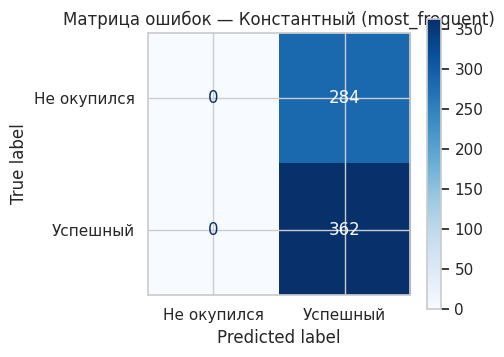

In [8]:
results = []

dummy_mf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
res = evaluate_model(dummy_mf, X_train, y_train, X_test, y_test,
                     model_name='Константный (most_frequent)')
results.append(res)

=== Константный (stratified) ===
F1-macro (test):  0.4975
ROC-AUC  (test):  0.4976

              precision    recall  f1-score   support

 Не окупился       0.44      0.43      0.43       284
    Успешный       0.56      0.57      0.56       362

    accuracy                           0.51       646
   macro avg       0.50      0.50      0.50       646
weighted avg       0.50      0.51      0.51       646



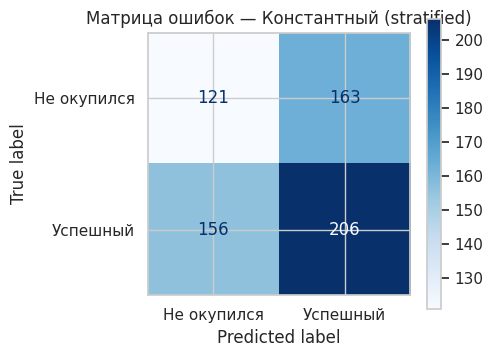

In [9]:
dummy_st = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
res = evaluate_model(dummy_st, X_train, y_train, X_test, y_test,
                     model_name='Константный (stratified)')
results.append(res)

**Вывод по константным бейзлайнам:**

- `most_frequent` даёт F1-macro = **0.3591** и ROC-AUC = **0.5000**. Модель всегда предсказывает класс 1 («Успешный»), полностью игнорируя класс 0 — recall класса 0 = 0.00. ROC-AUC = 0.5 соответствует случайному ранжированию: `DummyClassifier` не строит реальных вероятностей. Это нижняя планка по F1-macro.
- `stratified` даёт F1-macro = **0.4975** и ROC-AUC = **0.4976**. ROC-AUC чуть ниже 0.5 — это нормально для случайной стратегии: при конкретном `random_state` случайные предсказания могут незначительно «инвертироваться» относительно 0.5, реального предсказательного сигнала нет.

Любая обученная ML-модель должна давать F1-macro > 0.50.

---
## 6. Предобработка признаков

### Выбор признаков и обоснование предобработки

По итогам ДЗ №1 определены следующие признаки и стратегии их обработки:

**Числовые признаки:** `budget`, `runtime`, `vote_average`, `release_year`, `release_month`
- `budget` — сильная правосторонняя асимметрия (skew=2.09), применяем `log1p`-трансформацию через `FunctionTransformer`, затем `RobustScaler` .
- `runtime` — умеренная асимметрия, пропуски → заполняем медианой через `SimpleImputer`, затем `RobustScaler`.
- `vote_average`, `release_year`, `release_month` — масштабируем `RobustScaler`.

**Категориальные признаки:** `genre`, `original_language`




In [10]:
from sklearn.preprocessing import FunctionTransformer

BUDGET_COL = ['budget']
NUM_COLS = ['runtime', 'vote_average', 'release_year', 'release_month']
CAT_COLS = ['genre', 'original_language']

budget_pipeline = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', RobustScaler()),
])

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])


categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', TargetEncoder()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('budget', budget_pipeline, BUDGET_COL),
        ('numeric', numeric_pipeline, NUM_COLS),
        ('categorical', categorical_pipeline, CAT_COLS),
    ],
    remainder='drop',
)

print("Препроцессор собран:")
print(preprocessor)

Препроцессор собран:
ColumnTransformer(transformers=[('budget',
                                 Pipeline(steps=[('log1p',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', RobustScaler())]),
                                 ['budget']),
                                ('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['runtime', 'vote_average', 'release_year',
                                  'release_month']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                

---
## 7. Бейзлайн №1: Логистическая регрессия

Логистическая регрессия — первый кандидат в качестве простого ML-бейзлайна. Это линейная модель, требующая:
- Масштабирования признаков (выполнено через `RobustScaler`).
- Числовых входных данных (выполнено через Target Encoding категорий).
- Обработки пропусков (выполнено через `SimpleImputer`).

Используем `solver='lbfgs'`, `max_iter=1000` для надёжной сходимости, `class_weight='balanced'` — чтобы автоматически учесть дисбаланс классов (56%/44%).

=== Логистическая регрессия ===
F1-macro (test):  0.6228
ROC-AUC  (test):  0.6953

              precision    recall  f1-score   support

 Не окупился       0.57      0.62      0.59       284
    Успешный       0.68      0.63      0.65       362

    accuracy                           0.63       646
   macro avg       0.62      0.62      0.62       646
weighted avg       0.63      0.63      0.63       646



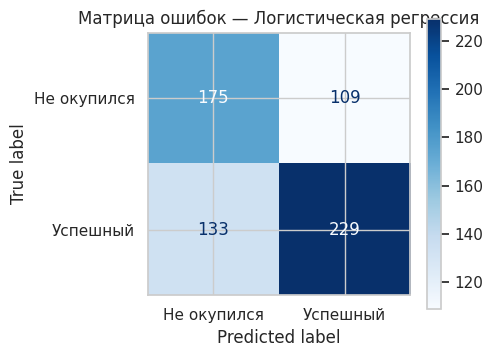

In [11]:
logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

res = evaluate_model(
    logreg_pipeline, X_train, y_train, X_test, y_test,
    model_name='Логистическая регрессия'
)
results.append(res)

**Вывод:** Логистическая регрессия даёт **F1-macro = 0.6228** и **ROC-AUC = 0.6953** на тестовой выборке — на 0.13 выше константного бейзлайна по F1. Модель примерно одинаково распознаёт оба класса (recall 0.62 и 0.63), что говорит о корректной работе `class_weight='balanced'`. По ROC-AUC логистическая регрессия показывает **лучший результат среди всех трёх ML-бейзлайнов (0.6953)**.

---
## 8. Бейзлайн №2: Дерево решений

Дерево решений — нелинейная модель, не требующая масштабирования признаков. Выбрано как второй бейзлайн, так как:
- Устойчиво к разным масштабам признаков.
- Работает с числовыми и закодированными категориальными данными.
- Интерпретируемо — можно визуализировать правила принятия решений.

Ограничиваем глубину `max_depth=5`, чтобы избежать переобучения на тренировочных данных. `class_weight='balanced'` — учёт дисбаланса.

=== Дерево решений (max_depth=5) ===
F1-macro (test):  0.6294
ROC-AUC  (test):  0.6816

              precision    recall  f1-score   support

 Не окупился       0.61      0.52      0.56       284
    Успешный       0.66      0.74      0.70       362

    accuracy                           0.64       646
   macro avg       0.64      0.63      0.63       646
weighted avg       0.64      0.64      0.64       646



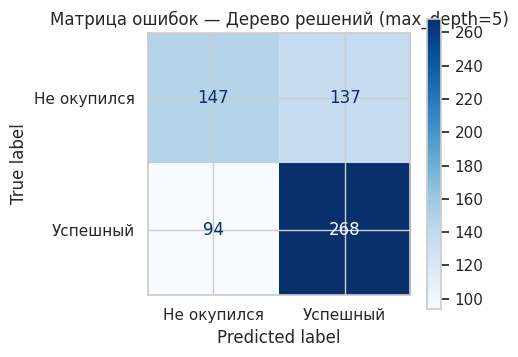

In [12]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('budget', FunctionTransformer(np.log1p, validate=False), BUDGET_COL),
        ('numeric', SimpleImputer(strategy='median'), NUM_COLS),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', TargetEncoder()),
        ]), CAT_COLS),
    ],
    remainder='drop',
)

tree_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

res = evaluate_model(
    tree_pipeline, X_train, y_train, X_test, y_test,
    model_name='Дерево решений (max_depth=5)'
)
results.append(res)

**Вывод:** Дерево решений даёт **F1-macro = 0.6294** и **ROC-AUC = 0.6816** — лучший результат по F1-macro среди трёх ML-бейзлайнов, однако разрыв с логистической регрессией невелик (0.6294 vs 0.6228). При этом по ROC-AUC дерево уступает и логистической регрессии, и KNN. Важный нюанс: recall класса 0 у дерева = **0.52** — хуже, чем у логистической регрессии (0.62), что означает, что дерево чаще пропускает убыточные фильмы.

---
## 9. Бейзлайн №3: k-Ближайших соседей (KNN)

KNN — метрический алгоритм, **требующий обязательного масштабирования** (иначе признаки с большим диапазоном доминируют в расстоянии). Именно поэтому для KNN используем полный препроцессор с `RobustScaler`.

Выбираем `n_neighbors=11` (нечётное — исключает ничьи) как разумный стартовый параметр для выборки ~2500 объектов.

=== KNN (n_neighbors=11) ===
F1-macro (test):  0.6071
ROC-AUC  (test):  0.6533

              precision    recall  f1-score   support

 Не окупился       0.57      0.53      0.55       284
    Успешный       0.65      0.69      0.67       362

    accuracy                           0.62       646
   macro avg       0.61      0.61      0.61       646
weighted avg       0.61      0.62      0.61       646



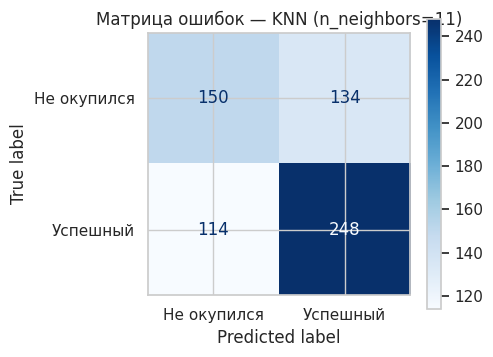

In [13]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(
        n_neighbors=11,
        weights='distance',
        metric='euclidean',
    )),
])

res = evaluate_model(
    knn_pipeline, X_train, y_train, X_test, y_test,
    model_name='KNN (n_neighbors=11)'
)
results.append(res)

**Вывод:** KNN даёт **F1-macro = 0.6071** и **ROC-AUC = 0.6533** — наихудший результат среди трёх ML-моделей по обеим метрикам. Recall класса 0 = **0.53** — модель плохо обнаруживает убыточные фильмы. KNN чувствителен к выбору `n_neighbors` и метрики расстояния;

---
## 10. Кросс-валидация лучшей модели

Для более надёжной оценки качества применяем **стратифицированную 5-fold кросс-валидацию** на тренировочной выборке. Это позволяет оценить стабильность модели и снизить дисперсию оценки метрики.

Используем `Pipeline` — это гарантирует, что Target Encoder обучается только на фолде обучения и не «видит» валидационный фолд (нет data leakage).

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for pipeline, name in [
    (logreg_pipeline, 'Логистическая регрессия'),
    (tree_pipeline,   'Дерево решений'),
    (knn_pipeline,    'KNN'),
]:
    cv_f1 = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )
    cv_auc = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    print(f'{name}:')
    print(f'  CV F1-macro:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
    print(f'  CV ROC-AUC:   {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print()

Логистическая регрессия:
  CV F1-macro:  0.6314 ± 0.0171
  CV ROC-AUC:   0.6807 ± 0.0180

Дерево решений:
  CV F1-macro:  0.6190 ± 0.0211
  CV ROC-AUC:   0.6673 ± 0.0113

KNN:
  CV F1-macro:  0.6188 ± 0.0183
  CV ROC-AUC:   0.6714 ± 0.0187



**Вывод по кросс-валидации:**

| Модель | CV F1-macro | CV ROC-AUC | Test F1-macro | Test ROC-AUC |
|---|---|---|---|---|
| Логистическая регрессия | 0.6314 ± 0.0171 | 0.6807 ± 0.0180 | 0.6228 | 0.6953 |
| Дерево решений | 0.6190 ± 0.0211 | 0.6673 ± 0.0113 | 0.6294 | 0.6816 |
| KNN | 0.6188 ± 0.0183 | 0.6714 ± 0.0187 | 0.6071 | 0.6533 |

Кросс-валидация подтверждает стабильность моделей (std < 0.022). По CV лидирует **логистическая регрессия (0.6314)** — она же даёт лучший CV ROC-AUC (0.6807). На тесте дерево незначительно обходит её по F1 (0.6294 vs 0.6228), но с учётом разброса CV (±0.02) это в пределах нормальной дисперсии и не является статистически значимым превосходством. Итоговый выбор бейзлайна: **логистическая регрессия** — стабильнее по CV, интерпретируема, лидирует по ROC-AUC.

---
## 11. Итоговое сравнение моделей

In [15]:
results_df = pd.DataFrame(results).set_index('model')
results_df = results_df.sort_values('f1_macro', ascending=False)
print(results_df.to_string())

                              f1_macro  roc_auc
model                                          
Дерево решений (max_depth=5)    0.6294   0.6816
Логистическая регрессия         0.6228   0.6953
KNN (n_neighbors=11)            0.6071   0.6533
Константный (stratified)        0.4975   0.4976
Константный (most_frequent)     0.3591   0.5000


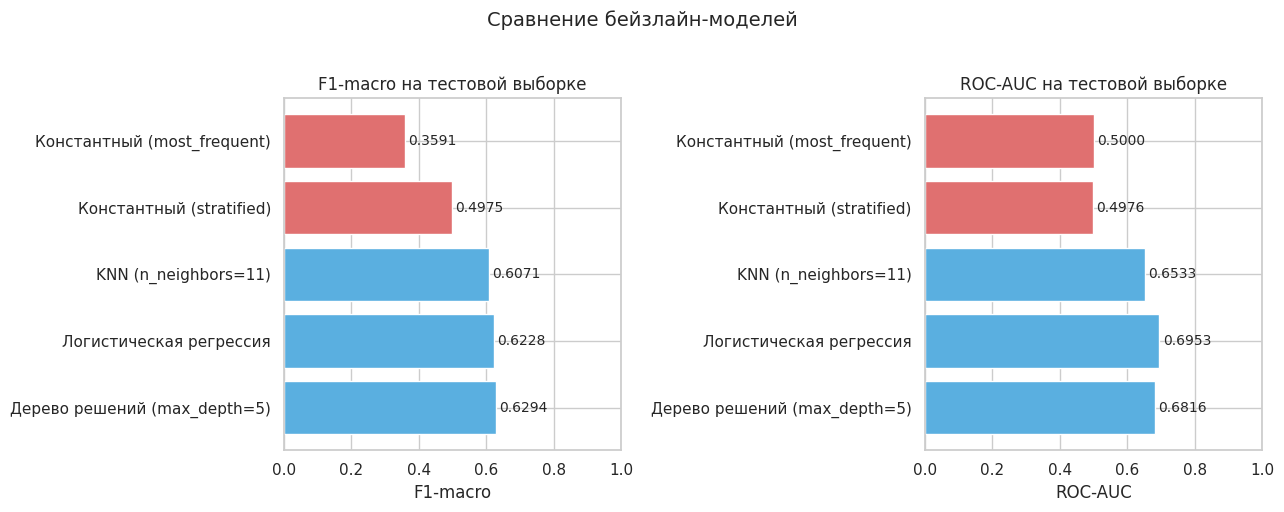

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#5aafe0' if 'Константный' not in m else '#e07070'
          for m in results_df.index]

axes[0].barh(results_df.index, results_df['f1_macro'], color=colors)
axes[0].set_xlim(0, 1)
axes[0].set_title('F1-macro на тестовой выборке', fontsize=12)
axes[0].set_xlabel('F1-macro')
for i, v in enumerate(results_df['f1_macro']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

axes[1].barh(results_df.index, results_df['roc_auc'], color=colors)
axes[1].set_xlim(0, 1)
axes[1].set_title('ROC-AUC на тестовой выборке', fontsize=12)
axes[1].set_xlabel('ROC-AUC')
for i, v in enumerate(results_df['roc_auc']):
    if not np.isnan(v):
        axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

plt.suptitle('Сравнение бейзлайн-моделей', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 12. Итоговые выводы

**Результаты бейзлайнов (тестовая выборка, RANDOM_STATE=123):**

| Модель | F1-macro | ROC-AUC |
|---|---|---|
| Константный (most_frequent) | 0.3591 | 0.5000 |
| Константный (stratified) | 0.4975 | 0.4976 |
| **Дерево решений (depth=5)** | **0.6294** | 0.6816 |
| Логистическая регрессия | 0.6228 | **0.6953** |
| KNN (k=11) | 0.6071 | 0.6533 |

Все три ML-модели **существенно превосходят** константный бейзлайн по F1-macro (+0.11–0.13), что подтверждает наличие предсказательного сигнала в признаках.

**Лучший бейзлайн по F1-macro на тесте** — Дерево решений (0.6294), однако разрыв с логистической регрессией незначителен (0.0066). По ROC-AUC и по CV лидирует логистическая регрессия (CV F1=0.6314, ROC-AUC=0.6953). С учётом стабильности по кросс-валидации и интерпретируемости **итоговый бейзлайн — логистическая регрессия**.

**Насколько результаты релевантны?** F1-macro ~0.62–0.63 при дисбалансе 56/44 — ожидаемый умеренный результат для простых моделей на ограниченном наборе из 7 признаков. Главное ограничение: признаки с наибольшей предсказательной силой (`vote_count`, `popularity`, `revenue`) исключены из-за data leakage — они формируются после/из целевой переменной. На признаках, доступных до выхода фильма, задача объективно сложна.